In [ ]:
!pip install node2vec
!pip install torch torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 22.3 MB/s eta 0:00:00
  Attempting uninstall: networkx
    Found existing installation: networkx 3.3
    Uninstalling networkx-3.3:
      Successfully uninstalled networkx-3.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.3.0+cu121 requires nvidia-cublas-cu12==12.1.3.1; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.0+cu121 requires nvidia-cuda-cupti-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.0+cu121 requires nvidia-cuda-nvrtc-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.0+cu121 requires nvidia-cuda-runtime-cu12==12.1.105; platform_system == "Linux" and platform_machine == "x86_64", which is not installed.
torch 2.3.

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.6 MB/s eta 0:00:00
  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (23.7 MB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (823 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl (14.1 MB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl (731.7 MB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl (410.6 MB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl (121.6 MB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl (56.5 MB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl (124.2 MB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl (196.0 MB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl (176.2 MB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manyl

In [ ]:
import json
import networkx as nx
from collections import Counter
import copy
from sklearn.model_selection import StratifiedShuffleSplit
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Load data from CSV files
user_data = pd.read_csv('lastfm_asia_target.csv')
edge_data = pd.read_csv('lastfm_asia_edges.csv')

# Load artist data from JSON file
with open('lastfm_asia_features.json') as f:
    artist_data = json.load(f)

In [ ]:
# Create a graph object
G = nx.Graph()

# Add nodes to the graph
for user_id, country in user_data.values:
    G.add_node(user_id, country=country)

# Add edges to the graph
for source, target in edge_data.values:
    G.add_edge(source, target)

# Add artist information to nodes (with check)
for user_id, artists in artist_data.items():
    user_id = int(user_id)
    if user_id in G.nodes:  # Check if node exists in the graph
        G.nodes[user_id]['artists'] = artists
    else:
        print(f"Warning: Skipping user {user_id} - not found in graph")


In [ ]:
# Print the number of nodes and edeges in the graph
print("Number of nodes in graph:", G.number_of_nodes())
print("Number of edges in graph:", G.number_of_edges())


Number of nodes in graph: 7624
Number of edges in graph: 27806


# **Preprocessing**

In [ ]:
print(f"Number of nodes with degree less then 2: {len([node for node, degree in G.degree() if degree < 2])}")

Number of nodes with degree less then 2: 1754


In [ ]:
# Filter nodes with degree less than 2
G_filtered = copy.deepcopy(G)
G_filtered = G_filtered.subgraph([node for node, degree in G.degree() if degree >= 2])


# Print the number of nodes and edges in the filtered graph
print("Number of nodes in filtered graph:", G_filtered.number_of_nodes())
print("Number of edges in filtered graph:", G_filtered.number_of_edges())
# Check for nodes with degree 0 after filtering
num_isolated_nodes = len([node for node, degree in G_filtered.degree() if degree == 0])
print(f"Number of isolated nodes after filtering: {num_isolated_nodes}")
# Calculate decrease in nodes as a percentage
decrease_nodes_percent = (1 - G_filtered.number_of_nodes() / G.number_of_nodes()) * 100
print(f"Decrease in {decrease_nodes_percent:.5f}% of the nodes")
# Calculate decrease in edges as a percentage
decrease_edges_percent = (1 - G_filtered.number_of_edges() / G.number_of_edges()) * 100
print(f"Decrease in {decrease_edges_percent:.5f}% of the edges")
print()

Number of nodes in filtered graph: 5870
Number of edges in filtered graph: 26052
Number of isolated nodes after filtering: 0
Decrease in 23.00630% of the nodes
Decrease in 6.30799% of the edges



# **Splitting the Network for Train and Test**

### country distribution

In [ ]:
countries = list(set([G.nodes[node]['country'] for node in G.nodes]))
def plot_country_distribution(country_counter, title):
    print("Country distribution:")
    for contry in countries:
        if contry in country_counter:
            print(f"{contry}: {country_counter[contry]}")
        else:
            print(f"{contry}: 0")
    print("\nTotal number of nodes:", sum(country_counter.values()), "\n")

    plt.bar(country_counter.keys(), country_counter.values())
    plt.title(title)
    plt.xlabel("Country")
    plt.ylabel("Number of users")
    plt.xticks(countries)
    plt.show()

Country distribution:
0: 863
1: 47
2: 59
3: 404
4: 4
5: 276
6: 488
7: 68
8: 385
9: 40
10: 1011
11: 113
12: 37
13: 51
14: 459
15: 217
16: 181
17: 1167

Total number of nodes: 5870 



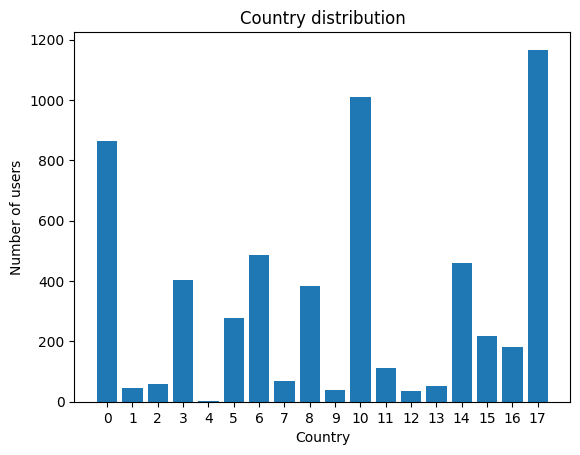

In [ ]:
# plot the country distribution
country_counter = Counter(nx.get_node_attributes(G_filtered, 'country').values())
plot_country_distribution(country_counter, "Country distribution")

### Splitting

In [ ]:
# Define train size (70%)
train_size = 0.7

# Stratified Split with ShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=1-train_size, random_state=42)

# Prepare data for split (features and target)
node_ids = list(G_filtered.nodes())
targets = [G_filtered.nodes[node]['country'] for node in node_ids]

# Perform Stratified Split
for train_index, test_index in sss.split(node_ids, targets):
    train_nodes = [node_ids[i] for i in train_index]
    test_nodes = [node_ids[i] for i in test_index]

# remove the country attribute from the test labels
for node in test_nodes:
    G_filtered.nodes[node].pop('country', None)

In [ ]:
print("Number of nodes in filtered graph:", G_filtered.number_of_nodes())

print("Number of nodes in training set:", len(train_nodes))
print("Number of nodes in testing set:", len(test_nodes))

Number of nodes in filtered graph: 5870
Number of nodes in training set: 4108
Number of nodes in testing set: 1762


# **Extracting Node-level Features**

### **Classical Node-level Features**
*	**Degree Centrality:** Measures the number of connections a node has.
*	**PageRank:** Estimates a node's importance based on its connections to other important nodes.
*	**Community Membership:** Identifies the community a node belongs to based on network structure.


In [ ]:
degree_centralities = nx.degree_centrality(G_filtered)
nx.set_node_attributes(G_filtered, degree_centralities, 'degree_centrality')

In [ ]:
pagerank_centralities = nx.pagerank(G_filtered)
nx.set_node_attributes(G_filtered, pagerank_centralities, 'pagerank_centralities')

In [ ]:
communities = nx.community.louvain_communities(G_filtered)
community_dict = {i: node_ids for i, node_ids in enumerate(communities, start=1)}
for community_id, ids in community_dict.items():
  for node_id in ids:
    nx.set_node_attributes(G_filtered, {node_id:community_id}, 'community_id')

### **Label-based Node Features:**
* **Neighbor Label Distribution:** Calculates the proportion of neighbors from each country for a target node.


In [ ]:
# Neighbor Label Distribution
for node_id in G_filtered.nodes():
    all_neighbors = list(G_filtered.neighbors(node_id))
    train_neighbors = [
        neighbor for neighbor in all_neighbors if neighbor in train_nodes
    ]
    train_neighbors_countries = [
        G_filtered.nodes[neighbor]["country"] for neighbor in train_neighbors
    ]
    country_counts = Counter(train_neighbors_countries)

    # Normalize counts to get proportions
    label_distribution = {i:0 for i in range(18)} # in case there are no neighbors
    if len(train_neighbors) > 0:
        for country, count in country_counts.items():
          label_distribution[country] = count / len(train_neighbors)

    # Update node attribute with distribution
    G_filtered.nodes[node_id]["neighbor_distribution"] = label_distribution

### **Artist-based Node Features:**


* **Top 10% Artist Popularity**: Counts the top 10% popular artists within all a node listens to.
* **Artist Similarity**: Calculates the similarity between the artists a node and his neighbors listens to. The similarity is calculated as the Jaccard similarity between the sets of artists.



In [ ]:
# Top 10% artists user listen to
artists = []
for node_id in G_filtered.nodes():
  for artist in G_filtered.nodes[node_id]['artists']:
    artists.append(artist)
# count popularity
artists_popularity = Counter(artists)
sorted_artists = sorted(artists_popularity.items(), key=lambda x: x[1], reverse=True)
top_32 = [item[0] for item in sorted_artists[:32]]

for node_id in G_filtered.nodes():
  c = 0
  for artist in G_filtered.nodes[node_id]['artists']:
    if artist in top_32:
      c += 1
  G_filtered.nodes[node_id]['top_32_artists'] = c


In [ ]:
# Artist Similarity:
for node_id in G_filtered.nodes():
    neighbor_artists = [G_filtered.nodes[neighbor]['artists'] for neighbor in G_filtered.neighbors(node_id)]
    all_artists = [artist for artists in neighbor_artists for artist in artists]
    artist_set = set(all_artists)
    artist_similarities = 0

    node_artist_set = set(G_filtered.nodes[node_id]['artists'])
    # calculate_artist_similarity
    intersection_size = len(artist_set.intersection(node_artist_set))
    union_size = len(artist_set.union(node_artist_set))
    if union_size > 0:
        artist_similarities = intersection_size / union_size
    nx.set_node_attributes(G_filtered, {node_id: artist_similarities}, 'artist_similarity')

### **Vector Representations of Nodes:**


*  **Node2Vec**: Embeds nodes into a vector space based on their network connections.



**Node2vec**

In [ ]:
import multiprocessing
from node2vec import Node2Vec

num_workers = min(multiprocessing.cpu_count(), 8)
node2vec = Node2Vec(G_filtered, dimensions=16, walk_length=15, num_walks=100, workers=num_workers)

# Embed nodes
node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=8)

for node_id in G_filtered.nodes():
  # Save node2vec embeddings in the node attributes
  nx.set_node_attributes(G_filtered, {node_id:node2vec_model.wv.get_vector(str(node_id))}, 'node2vec_embedding')

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

# **Training and Evaluating Node Classification Models**

###	Model Selection:
*	We choose XG-Boost machine learning algorithm for the node classification.


### The features of the 4 simple models:
##### classical centrality measures:
* 'degree_centrality'
* 'pagerank_centralities'
* 'community_id'

##### label based:
* 'neighbor_distribution'

##### artist based:
* 'top_32_artists'
* 'artist_similarity'

##### embedding based:
* 'node2vec_embedding'



In [ ]:
# using XGBoost
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score

# Define the parameter grid for grid search
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 8],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'objective': ['multi:softprob']
}


In [ ]:
y_train = [G_filtered.nodes[node_id]['country'] for node_id in train_nodes]
y_test = [G.nodes[node_id]['country'] for node_id in test_nodes]

In [ ]:
# model 1
X_train_classical = [
    [G_filtered.nodes[node_id]['degree_centrality'],
     G_filtered.nodes[node_id]['pagerank_centralities'],
     G_filtered.nodes[node_id]['community_id']]
    for node_id in train_nodes
]
X_test_classical = [
    [G_filtered.nodes[node_id]['degree_centrality'],
     G_filtered.nodes[node_id]['pagerank_centralities'],
     G_filtered.nodes[node_id]['community_id']]
    for node_id in test_nodes
]

# Create the XGBoost classifier object
xgb_model = XGBClassifier()
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_macro')
grid_search.fit(X_train_classical, y_train)

# Access the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions and evaluate the best model
y_pred = best_model.predict(X_test_classical)

print("XGBoost - Classical Features:")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test performance (F1-score):", f1_score(y_test, y_pred, average='macro'))


XGBoost - Classical Features:
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'objective': 'multi:softprob', 'subsample': 0.8}
Test accuracy: 0.7917139614074915
Test performance (F1-score): 0.6313331517897792


In [ ]:
# model 2
X_train_label = [
    list(G_filtered.nodes[node_id]['neighbor_distribution'].values())
    for node_id in train_nodes
]
X_test_label = [
    list(G_filtered.nodes[node_id]['neighbor_distribution'].values())
    for node_id in test_nodes
]

# Create the XGBoost classifier object
xgb_model = XGBClassifier()
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_macro')
grid_search.fit(X_train_label, y_train)

# Access the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions and evaluate the best model
y_pred = best_model.predict(X_test_label)

print("XGBoost - Label Features:")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test performance (F1-score):", f1_score(y_test, y_pred, average='macro'))

XGBoost - Label Features:
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 100, 'objective': 'multi:softprob', 'subsample': 0.6}
Test accuracy: 0.8762769580022701
Test performance (F1-score): 0.8129615215550934


In [ ]:
# model 3
X_train_artist = [
    [G_filtered.nodes[node_id]['top_32_artists'],
    G_filtered.nodes[node_id]['artist_similarity']]
    for node_id in train_nodes
]
X_test_artist = [
    [G_filtered.nodes[node_id]['top_32_artists'],
    G_filtered.nodes[node_id]['artist_similarity']]
    for node_id in test_nodes
]


# Create the XGBoost classifier object
xgb_model = XGBClassifier()
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_macro')
grid_search.fit(X_train_artist, y_train)

# Access the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions and evaluate the best model
y_pred = best_model.predict(X_test_artist)

print("XGBoost - Artists Features:")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test performance (F1-score):", f1_score(y_test, y_pred, average='macro'))

XGBoost - Artists Features:
Best parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 300, 'objective': 'multi:softprob', 'subsample': 0.6}
Test accuracy: 0.13904653802497163
Test performance (F1-score): 0.05923006465926676


In [ ]:
# model 4
X_train_embedding = [
    list(G_filtered.nodes[node_id]['node2vec_embedding'])
    for node_id in train_nodes
]
X_test_embedding = [
    list(G_filtered.nodes[node_id]['node2vec_embedding'])
    for node_id in test_nodes
]


# Create the XGBoost classifier object
xgb_model = XGBClassifier()
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_macro')
grid_search.fit(X_train_embedding, y_train)

# Access the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions and evaluate the best model
y_pred = best_model.predict(X_test_embedding)

print("XGBoost - Embedding Features:")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test performance (F1-score):", f1_score(y_test, y_pred, average='macro'))

XGBoost - Embedding Features:
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200, 'objective': 'multi:softprob', 'subsample': 0.6}
Test accuracy: 0.9006810442678774
Test performance (F1-score): 0.8289923812542513


**Combinned models**

In [ ]:
# Combining models- model 5 (1+4)
X_train_classical = [
    [
        G_filtered.nodes[node_id]['degree_centrality'],
        G_filtered.nodes[node_id]['pagerank_centralities'],
        G_filtered.nodes[node_id]['community_id'],
        *G_filtered.nodes[node_id]['node2vec_embedding']  # Unpack the embedding list
    ]
    for node_id in train_nodes
]

X_test_classical = [
    [G_filtered.nodes[node_id]['degree_centrality'],
     G_filtered.nodes[node_id]['pagerank_centralities'],
     G_filtered.nodes[node_id]['community_id'],
    *G_filtered.nodes[node_id]['node2vec_embedding']
     ]
     for node_id in test_nodes
]

# Create the XGBoost classifier object
xgb_model = XGBClassifier()
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_macro')
grid_search.fit(X_train_classical, y_train)

# Access the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions and evaluate the best model
y_pred = best_model.predict(X_test_classical)


print("XGBoost - classical features and Embedding features:")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test performance (F1-score):", f1_score(y_test, y_pred, average='macro'))

XGBoost - classical features and Embedding features:
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.2, 'max_depth': 8, 'n_estimators': 200, 'objective': 'multi:softprob', 'subsample': 0.6}
Test accuracy: 0.8995459704880817
Test performance (F1-score): 0.8254109012239897


In [ ]:
# Combining models- model 6 (2+4)
X_train_classical = [
    [*G_filtered.nodes[node_id]['neighbor_distribution'].values(),
     *G_filtered.nodes[node_id]['node2vec_embedding']]
     for node_id in train_nodes
]
X_test_classical = [
    [*G_filtered.nodes[node_id]['neighbor_distribution'].values(),
     *G_filtered.nodes[node_id]['node2vec_embedding']]
     for node_id in test_nodes
]

# Create the XGBoost classifier object
xgb_model = XGBClassifier()
# Perform grid search with cross-validation
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid, cv=3, scoring='f1_macro')
grid_search.fit(X_train_classical, y_train)

# Access the best model and parameters
best_model = grid_search.best_estimator_
best_params = grid_search.best_params_

# Make predictions and evaluate the best model
y_pred = best_model.predict(X_test_classical)


print("XGBoost - Label Features and Embedding Features:")
print("Best parameters:", best_params)
print("Test accuracy:", accuracy_score(y_test, y_pred))
print("Test performance (F1-score):", f1_score(y_test, y_pred, average='macro'))

XGBoost - Label Features and Embedding Features:
Best parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 300, 'objective': 'multi:softprob', 'subsample': 1.0}
Test accuracy: 0.9063564131668559
Test performance (F1-score): 0.8346587881542075


**sensitivity analysis for the dimentions attribute in  node2vec**

In [ ]:
import multiprocessing
from sklearn.metrics import accuracy_score, f1_score
from node2vec import Node2Vec
# Function to perform training and evaluation with specific node2vec parameters
def evaluate_node2vec_params(dimensions, walk_length, num_walks):
    # Create node2vec model with given parameters
    num_workers = min(multiprocessing.cpu_count(), 8)
    node2vec = Node2Vec(G_filtered, dimensions=dimensions, walk_length=walk_length, num_walks=num_walks, workers=num_workers)

    # Train the node2vec model
    node2vec_model = node2vec.fit(window=10, min_count=1, batch_words=8)

    for node_id in G_filtered.nodes():
      # Save node2vec embeddings in the node attributes
      nx.set_node_attributes(G_filtered, {node_id:node2vec_model.wv.get_vector(str(node_id))}, 'node2vec_embedding')

    # Embed nodes and create training/testing data
    X_train_embedding = [
        list(G_filtered.nodes[node_id]['node2vec_embedding'])
        for node_id in train_nodes
    ]
    X_test_embedding = [
        list(G_filtered.nodes[node_id]['node2vec_embedding'])
        for node_id in test_nodes
    ]

    # Create the XGBoost classifier object (using best hyperparameters)
    xgb_model = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100, objective=['multi:softprob'])

    # Train the XGBoost model
    xgb_model.fit(X_train_embedding, y_train)

    # Make predictions and evaluate the XGBoost model
    y_pred = xgb_model.predict(X_test_embedding)

    # Calculate accuracy and F1-score
    accuracy = accuracy_score(y_test, y_pred)
    f1_score_macro = f1_score(y_test, y_pred, average='macro')

    # Print results for this set of node2vec parameters
    print(f"Node2vec parameters: dimensions={dimensions}, walk_length={walk_length}, num_walks={num_walks}")
    print(f"Test accuracy: {accuracy}")
    print(f"Test F1-score: {f1_score_macro}")
    print("-" * 50)  # Separator for clarity

In [ ]:
evaluate_node2vec_params(dimensions=4, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=4, walk_length=15, num_walks=100
Test accuracy: 0.8700340522133939
Test F1-score: 0.7621808619446784
--------------------------------------------------


In [ ]:
evaluate_node2vec_params(dimensions=8, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=8, walk_length=15, num_walks=100
Test accuracy: 0.8916004540295119
Test F1-score: 0.812435898377704
--------------------------------------------------


In [ ]:
evaluate_node2vec_params(dimensions=16, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=16, walk_length=15, num_walks=100
Test accuracy: 0.8916004540295119
Test F1-score: 0.8106766391103991
--------------------------------------------------


In [ ]:
evaluate_node2vec_params(dimensions=24, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=24, walk_length=15, num_walks=100
Test accuracy: 0.8904653802497162
Test F1-score: 0.8143449728357772
--------------------------------------------------


In [ ]:
evaluate_node2vec_params(dimensions=32, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=32, walk_length=15, num_walks=100
Test accuracy: 0.8893303064699205
Test F1-score: 0.8041252336919095
--------------------------------------------------


In [ ]:
evaluate_node2vec_params(dimensions=64, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=64, walk_length=15, num_walks=100
Test accuracy: 0.8881952326901249
Test F1-score: 0.8048727788201048
--------------------------------------------------


In [ ]:
evaluate_node2vec_params(dimensions=100, walk_length=15, num_walks=100)

Computing transition probabilities:   0%|          | 0/5870 [00:00<?, ?it/s]

Node2vec parameters: dimensions=100, walk_length=15, num_walks=100
Test accuracy: 0.8921679909194098
Test F1-score: 0.8107389672565581
--------------------------------------------------
